# Dehazing con U-Net VGG16 + Pix2Pix — Google Colab T4

## 0. Google Drive + Dataset RESIDE-6K

In [8]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil, zipfile
from pathlib import Path

DRIVE_ROOT = Path('/content/drive/MyDrive/MLTarea3')
DRIVE_ROOT.mkdir(exist_ok=True)
CKPT_DIR = DRIVE_ROOT / 'checkpoints'
CKPT_DIR.mkdir(exist_ok=True)
DATA_DIR = DRIVE_ROOT / 'clear_images'
DATA_DIR.mkdir(exist_ok=True)

print('Drive montado.')
print('Checkpoints en:', CKPT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive montado.
Checkpoints en: /content/drive/MyDrive/MLTarea3/checkpoints


In [9]:
# ---- Descargar imágenes limpias de exterior (BSD500 + SUN397 subset) ----
# Ambos son públicos y descargables sin cuenta

if len(list(DATA_DIR.glob('*.jpg'))) < 100:
    print('Descargando BSD500...')
    os.system('wget -q https://www2.eecs.berkeley.edu/Research/Projects/CS/vision/grouping/BSR/BSR_bsds500.tgz -O /content/bsd.tgz')
    os.system('tar -xzf /content/bsd.tgz -C /content/')

    # Copiar todas las imagenes train+test+val a DATA_DIR
    import shutil
    for split in ['train', 'val', 'test']:
        src = Path(f'/content/BSR/BSDS500/data/images/{split}')
        if src.exists():
            for img in src.glob('*.jpg'):
                shutil.copy(img, DATA_DIR / img.name)
    os.remove('/content/bsd.tgz')
    print(f'BSD500 listo: {len(list(DATA_DIR.glob("*.jpg")))} imagenes')
else:
    print(f'Imagenes ya en Drive: {len(list(DATA_DIR.glob("*.jpg")))}')

Descargando BSD500...
BSD500 listo: 500 imagenes


In [11]:
import random
import numpy as np

random.seed(42)
all_clear = sorted(DATA_DIR.glob('*.jpg'))
random.shuffle(all_clear)

n_train     = int(len(all_clear) * 0.8)
train_clear = all_clear[:n_train]
val_clear   = all_clear[n_train:]

print(f'Imagenes limpias: {len(all_clear)}')
print(f'Pares efectivos train (x4 densidades): {len(train_clear) * 4}')
print(f'Pares efectivos val  (x4 densidades): {len(val_clear)   * 4}')

Imagenes limpias: 500
Pares efectivos train (x4 densidades): 1600
Pares efectivos val  (x4 densidades): 400


## 1. Imports y Configuracion

In [12]:
!pip install albumentations -q

import os, math, random
import numpy as np
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam

import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
from tqdm import tqdm

# ---- Reproducibilidad ----
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

# ---- Dispositivo ----
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Dispositivo:', DEVICE)
if DEVICE == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

# ---- Hiperparametros ----
IMG_SIZE   = 256
BATCH_SIZE = 8
NUM_EPOCHS = 35
LR_G       = 2e-4
LR_D       = 2e-4
LAMBDA_L1  = 100
PATCH_SIZE = 15
EVAL_EVERY = 5

Dispositivo: cuda
GPU: Tesla T4


## 2. Pares hazy/clear y DataLoaders

In [15]:

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

HAZE_LEVELS = [
    (0.85, 0.9),
    (0.65, 0.85),
    (0.45, 0.80),
    (0.25, 0.75),
]

train_tfm = A.Compose([
    A.RandomCrop(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05, p=0.3),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
], additional_targets={'mask': 'image'})

val_tfm = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
], additional_targets={'mask': 'image'})


class DehazeDataset(Dataset):
    def __init__(self, clear_files, transform, haze_levels=HAZE_LEVELS):
        self.files       = clear_files
        self.transform   = transform
        self.haze_levels = haze_levels

    def __len__(self):
        return len(self.files) * len(self.haze_levels)

    @staticmethod
    def add_haze(img_np, t, A):
        J = img_np.astype(np.float32) / 255.0
        I = J * t + A * (1 - t)
        return (np.clip(I, 0, 1) * 255).astype(np.uint8)

    def __getitem__(self, idx):
        file_idx  = idx // len(self.haze_levels)
        level_idx = idx  % len(self.haze_levels)
        t_range, A_range = self.haze_levels[level_idx]

        t = random.uniform(t_range - 0.05, t_range + 0.05)
        A = random.uniform(A_range - 0.05, A_range + 0.05)
        t = max(0.1, min(0.99, t))
        A = max(0.5, min(1.0,  A))

        clear_np = np.array(Image.open(self.files[file_idx]).convert('RGB'))
        hazy_np  = self.add_haze(clear_np, t, A)

        out = self.transform(image=hazy_np, mask=clear_np)
        return out['image'], out['mask']


train_loader = DataLoader(DehazeDataset(train_clear, train_tfm),
                          batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(DehazeDataset(val_clear, val_tfm),
                          batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True, persistent_workers=True)

x, y = next(iter(train_loader))
print(f'Train: {len(train_loader.dataset)} pares | Val: {len(val_loader.dataset)} pares')
print('Input shape:', x.shape, '| Target shape:', y.shape)

Train: 1600 pares | Val: 400 pares
Input shape: torch.Size([8, 3, 256, 256]) | Target shape: torch.Size([8, 3, 256, 256])


## 3. Dark Channel Prior

In [16]:
def dark_channel_prior(x: torch.Tensor, patch_size: int = 15) -> torch.Tensor:
    """
    x : (B, 3, H, W) normalizado ImageNet
    Retorna (B, 3, H, W) dark channel replicado en espacio [0,1]
    """
    mean = torch.tensor(MEAN, device=x.device, dtype=x.dtype).view(1,3,1,1)
    std  = torch.tensor(STD,  device=x.device, dtype=x.dtype).view(1,3,1,1)
    x01  = (x * std + mean).clamp(0, 1)
    min_ch = torch.min(x01, dim=1, keepdim=True)[0]
    pad    = patch_size // 2
    dc     = -F.max_pool2d(-min_ch, kernel_size=patch_size, stride=1, padding=pad)
    return dc.repeat(1, 3, 1, 1)

with torch.no_grad():
    _dc = dark_channel_prior(x.to(DEVICE))
print('DCP shape:', _dc.shape, '| rango: [{:.3f}, {:.3f}]'.format(_dc.min().item(), _dc.max().item()))

DCP shape: torch.Size([8, 3, 256, 256]) | rango: [0.063, 0.871]


## 4. Generador VGG16-UNet

In [17]:
def _disable_inplace(module: nn.Module):
    for m in module.modules():
        if isinstance(m, nn.ReLU):
            m.inplace = False

def _conv_bn_relu(in_ch, out_ch):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=False),
    )


class VGG16UNet(nn.Module):
    def __init__(self, patch_size: int = 15):
        super().__init__()
        self.patch_size = patch_size

        vgg   = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        feats = list(vgg.features.children())

        # ---- Entrada duplicada (MariGold) ----
        conv1 = feats[0]
        self.conv_rgb = nn.Conv2d(3, 64, 3, padding=1, bias=True)
        self.conv_dcp = nn.Conv2d(3, 64, 3, padding=1, bias=True)
        with torch.no_grad():
            self.conv_rgb.weight.copy_(conv1.weight * 0.5)
            self.conv_dcp.weight.copy_(conv1.weight * 0.5)
            if conv1.bias is not None:
                self.conv_rgb.bias.copy_(conv1.bias * 0.5)
                self.conv_dcp.bias.copy_(conv1.bias * 0.5)
        self.relu0 = nn.ReLU(inplace=False)

        # ---- Encoder VGG16 ----
        self.enc1 = nn.Sequential(*feats[1:4])    # 64ch,  256x256
        self.enc2 = nn.Sequential(*feats[4:9])    # 128ch, 128x128
        self.enc3 = nn.Sequential(*feats[9:16])   # 256ch,  64x64
        self.enc4 = nn.Sequential(*feats[16:23])  # 512ch,  32x32
        self.enc5 = nn.Sequential(*feats[23:30])  # 512ch,  16x16
        for enc in [self.enc1, self.enc2, self.enc3, self.enc4, self.enc5]:
            _disable_inplace(enc)

        self.bottleneck = _conv_bn_relu(512, 512)

        # ---- Decoder (4 niveles: 16->32->64->128->256) ----
        self.up5  = nn.ConvTranspose2d(512, 512, 2, stride=2)
        self.dec5 = _conv_bn_relu(512 + 512, 512)  # cat s5: 1024->512

        self.up4  = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec4 = _conv_bn_relu(256 + 256, 256)  # cat s4: 512->256

        self.up3  = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = _conv_bn_relu(128 + 128, 128)  # cat s3: 256->128

        self.up2  = nn.ConvTranspose2d(128,  64, 2, stride=2)
        self.dec2 = _conv_bn_relu( 64 +  64,  64)  # cat s2: 128->64

        self.out_conv = nn.Conv2d(64, 3, 1)

    def forward(self, x):
        dcp = dark_channel_prior(x, self.patch_size)
        s1  = self.relu0(self.conv_rgb(x) + self.conv_dcp(dcp))

        s2 = self.enc1(s1)
        s3 = self.enc2(s2)
        s4 = self.enc3(s3)
        s5 = self.enc4(s4)
        b  = self.enc5(s5)
        b  = self.bottleneck(b)

        d = self.dec5(torch.cat([self.up5(b), s5], dim=1))
        d = self.dec4(torch.cat([self.up4(d), s4], dim=1))
        d = self.dec3(torch.cat([self.up3(d), s3], dim=1))
        d = self.dec2(torch.cat([self.up2(d), s2], dim=1))
        return torch.tanh(self.out_conv(d))


with torch.no_grad():
    _G = VGG16UNet(PATCH_SIZE).to(DEVICE)
    _x = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    _y = _G(_x)
    print('VGG16UNet  Entrada:', _x.shape, '-> Salida:', _y.shape)
    print(f'Parametros: {sum(p.numel() for p in _G.parameters() if p.requires_grad):,}')
    del _G, _x, _y

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 84.1MB/s]


VGG16UNet  Entrada: torch.Size([2, 3, 256, 256]) -> Salida: torch.Size([2, 3, 256, 256])
Parametros: 25,083,459


## 5. Generador Baseline U-Net

In [18]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=False),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=False),
        )
    def forward(self, x): return self.net(x)


class BaselineUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = DoubleConv(  3,  64)
        self.enc2 = DoubleConv( 64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)
        self.pool = nn.MaxPool2d(2)
        self.neck = DoubleConv(512, 1024)

        self.up4  = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = DoubleConv(1024, 512)
        self.up3  = nn.ConvTranspose2d( 512, 256, 2, stride=2)
        self.dec3 = DoubleConv( 512, 256)
        self.up2  = nn.ConvTranspose2d( 256, 128, 2, stride=2)
        self.dec2 = DoubleConv( 256, 128)
        self.up1  = nn.ConvTranspose2d( 128,  64, 2, stride=2)
        self.dec1 = DoubleConv( 128,  64)
        self.out  = nn.Conv2d(64, 3, 1)

    def forward(self, x):
        s1 = self.enc1(x)
        s2 = self.enc2(self.pool(s1))
        s3 = self.enc3(self.pool(s2))
        s4 = self.enc4(self.pool(s3))
        b  = self.neck(self.pool(s4))
        d  = self.dec4(torch.cat([self.up4(b),  s4], dim=1))
        d  = self.dec3(torch.cat([self.up3(d),  s3], dim=1))
        d  = self.dec2(torch.cat([self.up2(d),  s2], dim=1))
        d  = self.dec1(torch.cat([self.up1(d),  s1], dim=1))
        return torch.tanh(self.out(d))


with torch.no_grad():
    _G = BaselineUNet().to(DEVICE)
    _x = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    _y = _G(_x)
    print('BaselineUNet  Entrada:', _x.shape, '-> Salida:', _y.shape)
    del _G, _x, _y

BaselineUNet  Entrada: torch.Size([2, 3, 256, 256]) -> Salida: torch.Size([2, 3, 256, 256])


## 6. Discriminador PatchGAN

In [19]:
class PatchGAN(nn.Module):
    def __init__(self):
        super().__init__()
        def blk(ic, oc, stride, norm=True):
            layers = [nn.Conv2d(ic, oc, 4, stride=stride, padding=1, bias=not norm)]
            if norm: layers.append(nn.BatchNorm2d(oc))
            layers.append(nn.LeakyReLU(0.2, inplace=False))
            return nn.Sequential(*layers)
        self.model = nn.Sequential(
            blk( 6,  64, 2, norm=False),
            blk(64, 128, 2),
            blk(128, 256, 2),
            blk(256, 512, 1),
            nn.Conv2d(512, 1, 4, stride=1, padding=1),
        )
    def forward(self, x_hazy, x_clear):
        return self.model(torch.cat([x_hazy, x_clear], dim=1))

with torch.no_grad():
    _D = PatchGAN().to(DEVICE)
    _x = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    print('PatchGAN salida:', _D(_x, _x).shape)
    del _D, _x

PatchGAN salida: torch.Size([2, 1, 30, 30])


## 7. Perdidas y Metricas

In [20]:
mse_loss = nn.MSELoss()
l1_loss  = nn.L1Loss()

def loss_D(D, x, y_real, y_fake):
    pr = D(x, y_real)
    pf = D(x, y_fake.detach())
    return 0.5 * (mse_loss(pr, torch.ones_like(pr)) +
                  mse_loss(pf, torch.zeros_like(pf)))

def loss_G(D, x, y_real, y_fake):
    pf    = D(x, y_fake)
    l_gan = mse_loss(pf, torch.ones_like(pf))
    l_l1  = l1_loss(y_fake, y_real)
    return l_gan + LAMBDA_L1 * l_l1, l_gan, l_l1

def psnr(pred, target):
    mse = F.mse_loss(pred, target).item()
    return 10 * math.log10(4.0 / mse) if mse > 0 else 100.0

print('Perdidas y metricas listas.')

Perdidas y metricas listas.


## 8. Bucle de Entrenamiento

In [21]:
def train(
    G: nn.Module,
    D: nn.Module,
    name: str,
    num_epochs: int = NUM_EPOCHS,
    eval_every: int = EVAL_EVERY,
    resume: bool = True,
) -> dict:

    G, D = G.to(DEVICE), D.to(DEVICE)
    opt_G = Adam(G.parameters(), lr=LR_G, betas=(0.5, 0.999))
    opt_D = Adam(D.parameters(), lr=LR_D, betas=(0.5, 0.999))
    scaler_G = torch.amp.GradScaler('cuda')
    scaler_D = torch.amp.GradScaler('cuda')

    history   = {'lG': [], 'lD': [], 'psnr': []}
    best_psnr = -float('inf')
    start_epoch = 1
    ckpt_path = CKPT_DIR / f'best_{name}.pth'

    # ---- Reanudar desde checkpoint si existe ----
    if resume and ckpt_path.exists():
        ckpt = torch.load(ckpt_path, map_location=DEVICE)
        G.load_state_dict(ckpt['G'])
        D.load_state_dict(ckpt['D'])
        opt_G.load_state_dict(ckpt['opt_G'])
        opt_D.load_state_dict(ckpt['opt_D'])
        best_psnr   = ckpt['psnr']
        start_epoch = ckpt['epoch'] + 1
        history     = ckpt.get('history', history)
        print(f'[{name}] Reanudando desde epoca {start_epoch} | mejor PSNR: {best_psnr:.2f} dB')
    else:
        print(f'[{name}] Entrenamiento desde cero.')

    if start_epoch > num_epochs:
        print(f'[{name}] Ya completo {num_epochs} epocas.')
        return history

    for epoch in range(start_epoch, num_epochs + 1):
        G.train(); D.train()
        run_lG = run_lD = 0.0

        pbar = tqdm(train_loader, desc=f'[{name}] {epoch}/{num_epochs}', leave=False)
        for x, y in pbar:
            x, y = x.to(DEVICE), y.to(DEVICE)

            # -- Discriminador --
            with torch.amp.autocast('cuda'):
                y_fake = G(x)
                ld     = loss_D(D, x, y, y_fake)
            opt_D.zero_grad()
            scaler_D.scale(ld).backward()
            scaler_D.step(opt_D)
            scaler_D.update()

            # -- Generador --
            with torch.amp.autocast('cuda'):
                y_fake        = G(x)
                lg, lgan, ll1 = loss_G(D, x, y, y_fake)
            opt_G.zero_grad()
            scaler_G.scale(lg).backward()
            nn.utils.clip_grad_norm_(G.parameters(), 1.0)
            scaler_G.step(opt_G)
            scaler_G.update()

            run_lG += lg.item(); run_lD += ld.item()
            pbar.set_postfix(lG=f'{lg.item():.3f}', lD=f'{ld.item():.3f}')

        n = len(train_loader)
        history['lG'].append(run_lG / n)
        history['lD'].append(run_lD / n)

        # -- Validacion y guardado --
        if epoch % eval_every == 0 or epoch == num_epochs:
            G.eval()
            val_psnr = 0.0
            with torch.no_grad():
                for x, y in val_loader:
                    x, y = x.to(DEVICE), y.to(DEVICE)
                    with torch.amp.autocast('cuda'):
                        yf = G(x)
                    val_psnr += psnr(yf.float(), y.float())
            val_psnr /= len(val_loader)
            history['psnr'].append(val_psnr)

            print(f'[{name}] Epoca {epoch:3d} | '
                  f'lG={history["lG"][-1]:.4f} | lD={history["lD"][-1]:.4f} | '
                  f'PSNR={val_psnr:.2f} dB')

            if val_psnr > best_psnr:
                best_psnr = val_psnr
                torch.save({
                    'epoch':   epoch,
                    'G':       G.state_dict(),
                    'D':       D.state_dict(),
                    'opt_G':   opt_G.state_dict(),
                    'opt_D':   opt_D.state_dict(),
                    'psnr':    val_psnr,
                    'history': history,
                }, ckpt_path)
                print(f'  -> Guardado en Drive: {ckpt_path}')

    return history

print('Bucle de entrenamiento listo.')

Bucle de entrenamiento listo.


## 9. Entrenamiento — VGG16-UNet

In [22]:
G_vgg = VGG16UNet(PATCH_SIZE)
D_vgg = PatchGAN()

history_vgg = train(G_vgg, D_vgg, name='VGG16_UNet')

[VGG16_UNet] Entrenamiento desde cero.


[VGG16_UNet] Epoca   5 | lG=37.1413 | lD=0.0141 | PSNR=13.16 dB
  -> Guardado en Drive: /content/drive/MyDrive/MLTarea3/checkpoints/best_VGG16_UNet.pth


[VGG16_UNet] Epoca  10 | lG=35.1854 | lD=0.3605 | PSNR=13.58 dB
  -> Guardado en Drive: /content/drive/MyDrive/MLTarea3/checkpoints/best_VGG16_UNet.pth


[VGG16_UNet] Epoca  15 | lG=34.7767 | lD=0.0111 | PSNR=13.75 dB
  -> Guardado en Drive: /content/drive/MyDrive/MLTarea3/checkpoints/best_VGG16_UNet.pth


[VGG16_UNet] Epoca  20 | lG=33.9039 | lD=0.0091 | PSNR=13.80 dB
  -> Guardado en Drive: /content/drive/MyDrive/MLTarea3/checkpoints/best_VGG16_UNet.pth


[VGG16_UNet] Epoca  25 | lG=33.0121 | lD=0.0072 | PSNR=13.42 dB


[VGG16_UNet] Epoca  30 | lG=32.5982 | lD=0.0069 | PSNR=13.76 dB


[VGG16_UNet] Epoca  35 | lG=32.0123 | lD=0.0034 | PSNR=13.97 dB
  -> Guardado en Drive: /content/drive/MyDrive/MLTarea3/checkpoints/best_VGG16_UNet.pth


## 10. Entrenamiento — Baseline U-Net

In [23]:
G_base = BaselineUNet()
D_base = PatchGAN()

history_base = train(G_base, D_base, name='Baseline_UNet')

[Baseline_UNet] Entrenamiento desde cero.


[Baseline_UNet] Epoca   5 | lG=40.5317 | lD=0.0137 | PSNR=13.18 dB
  -> Guardado en Drive: /content/drive/MyDrive/MLTarea3/checkpoints/best_Baseline_UNet.pth


[Baseline_UNet] Epoca  10 | lG=39.0870 | lD=0.0138 | PSNR=12.74 dB


[Baseline_UNet] Epoca  15 | lG=37.9296 | lD=0.0041 | PSNR=13.53 dB
  -> Guardado en Drive: /content/drive/MyDrive/MLTarea3/checkpoints/best_Baseline_UNet.pth


[Baseline_UNet] Epoca  20 | lG=37.7920 | lD=0.0110 | PSNR=13.73 dB
  -> Guardado en Drive: /content/drive/MyDrive/MLTarea3/checkpoints/best_Baseline_UNet.pth


[Baseline_UNet] Epoca  25 | lG=37.4875 | lD=0.0139 | PSNR=13.58 dB


[Baseline_UNet] Epoca  30 | lG=36.8386 | lD=0.1320 | PSNR=13.58 dB


[Baseline_UNet] Epoca  35 | lG=36.5458 | lD=0.0041 | PSNR=13.60 dB


## 11. Curvas de Entrenamiento

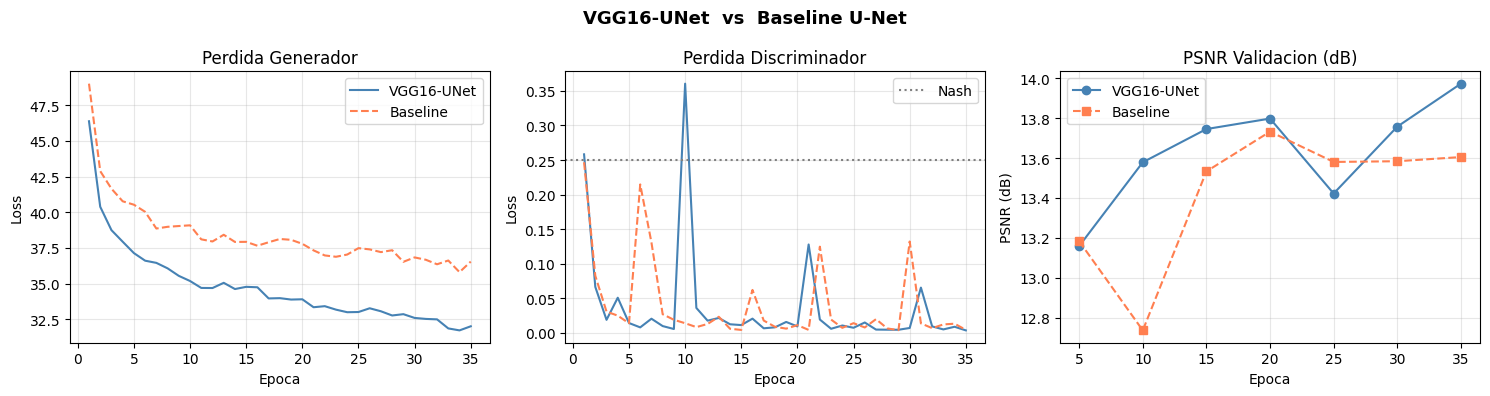

In [33]:
# Recargar historiales desde checkpoints si es necesario
def load_history(name):
    p = CKPT_DIR / f'best_{name}.pth'
    if p.exists():
        return torch.load(p, map_location='cpu').get('history', {'lG':[],'lD':[],'psnr':[]})
    return {'lG': [], 'lD': [], 'psnr': []}

if 'history_vgg' not in dir():  history_vgg  = load_history('VGG16_UNet')
if 'history_base' not in dir(): history_base = load_history('Baseline_UNet')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('VGG16-UNet  vs  Baseline U-Net', fontsize=13, fontweight='bold')

n_vgg  = len(history_vgg['lG'])
n_base = len(history_base['lG'])
ve     = range(EVAL_EVERY, n_vgg  + 1, EVAL_EVERY)
be     = range(EVAL_EVERY, n_base + 1, EVAL_EVERY)

axes[0].plot(range(1, n_vgg+1),  history_vgg['lG'],  label='VGG16-UNet', color='steelblue')
axes[0].plot(range(1, n_base+1), history_base['lG'], label='Baseline',   color='coral', ls='--')
axes[0].set_title('Perdida Generador')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(range(1, n_vgg+1),  history_vgg['lD'],  color='steelblue')
axes[1].plot(range(1, n_base+1), history_base['lD'], color='coral', ls='--')
axes[1].axhline(0.25, color='gray', ls=':', label='Nash')
axes[1].set_title('Perdida Discriminador')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(ve, history_vgg['psnr'],  label='VGG16-UNet', color='steelblue', marker='o')
axes[2].plot(be, history_base['psnr'], label='Baseline',   color='coral', marker='s', ls='--')
axes[2].set_title('PSNR Validacion (dB)')
axes[2].set_xlabel('Epoca')
axes[2].set_ylabel('PSNR (dB)')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(str(DRIVE_ROOT / 'curvas.png'), dpi=150)
plt.show()


## 12. Visualizacion Cualitativa

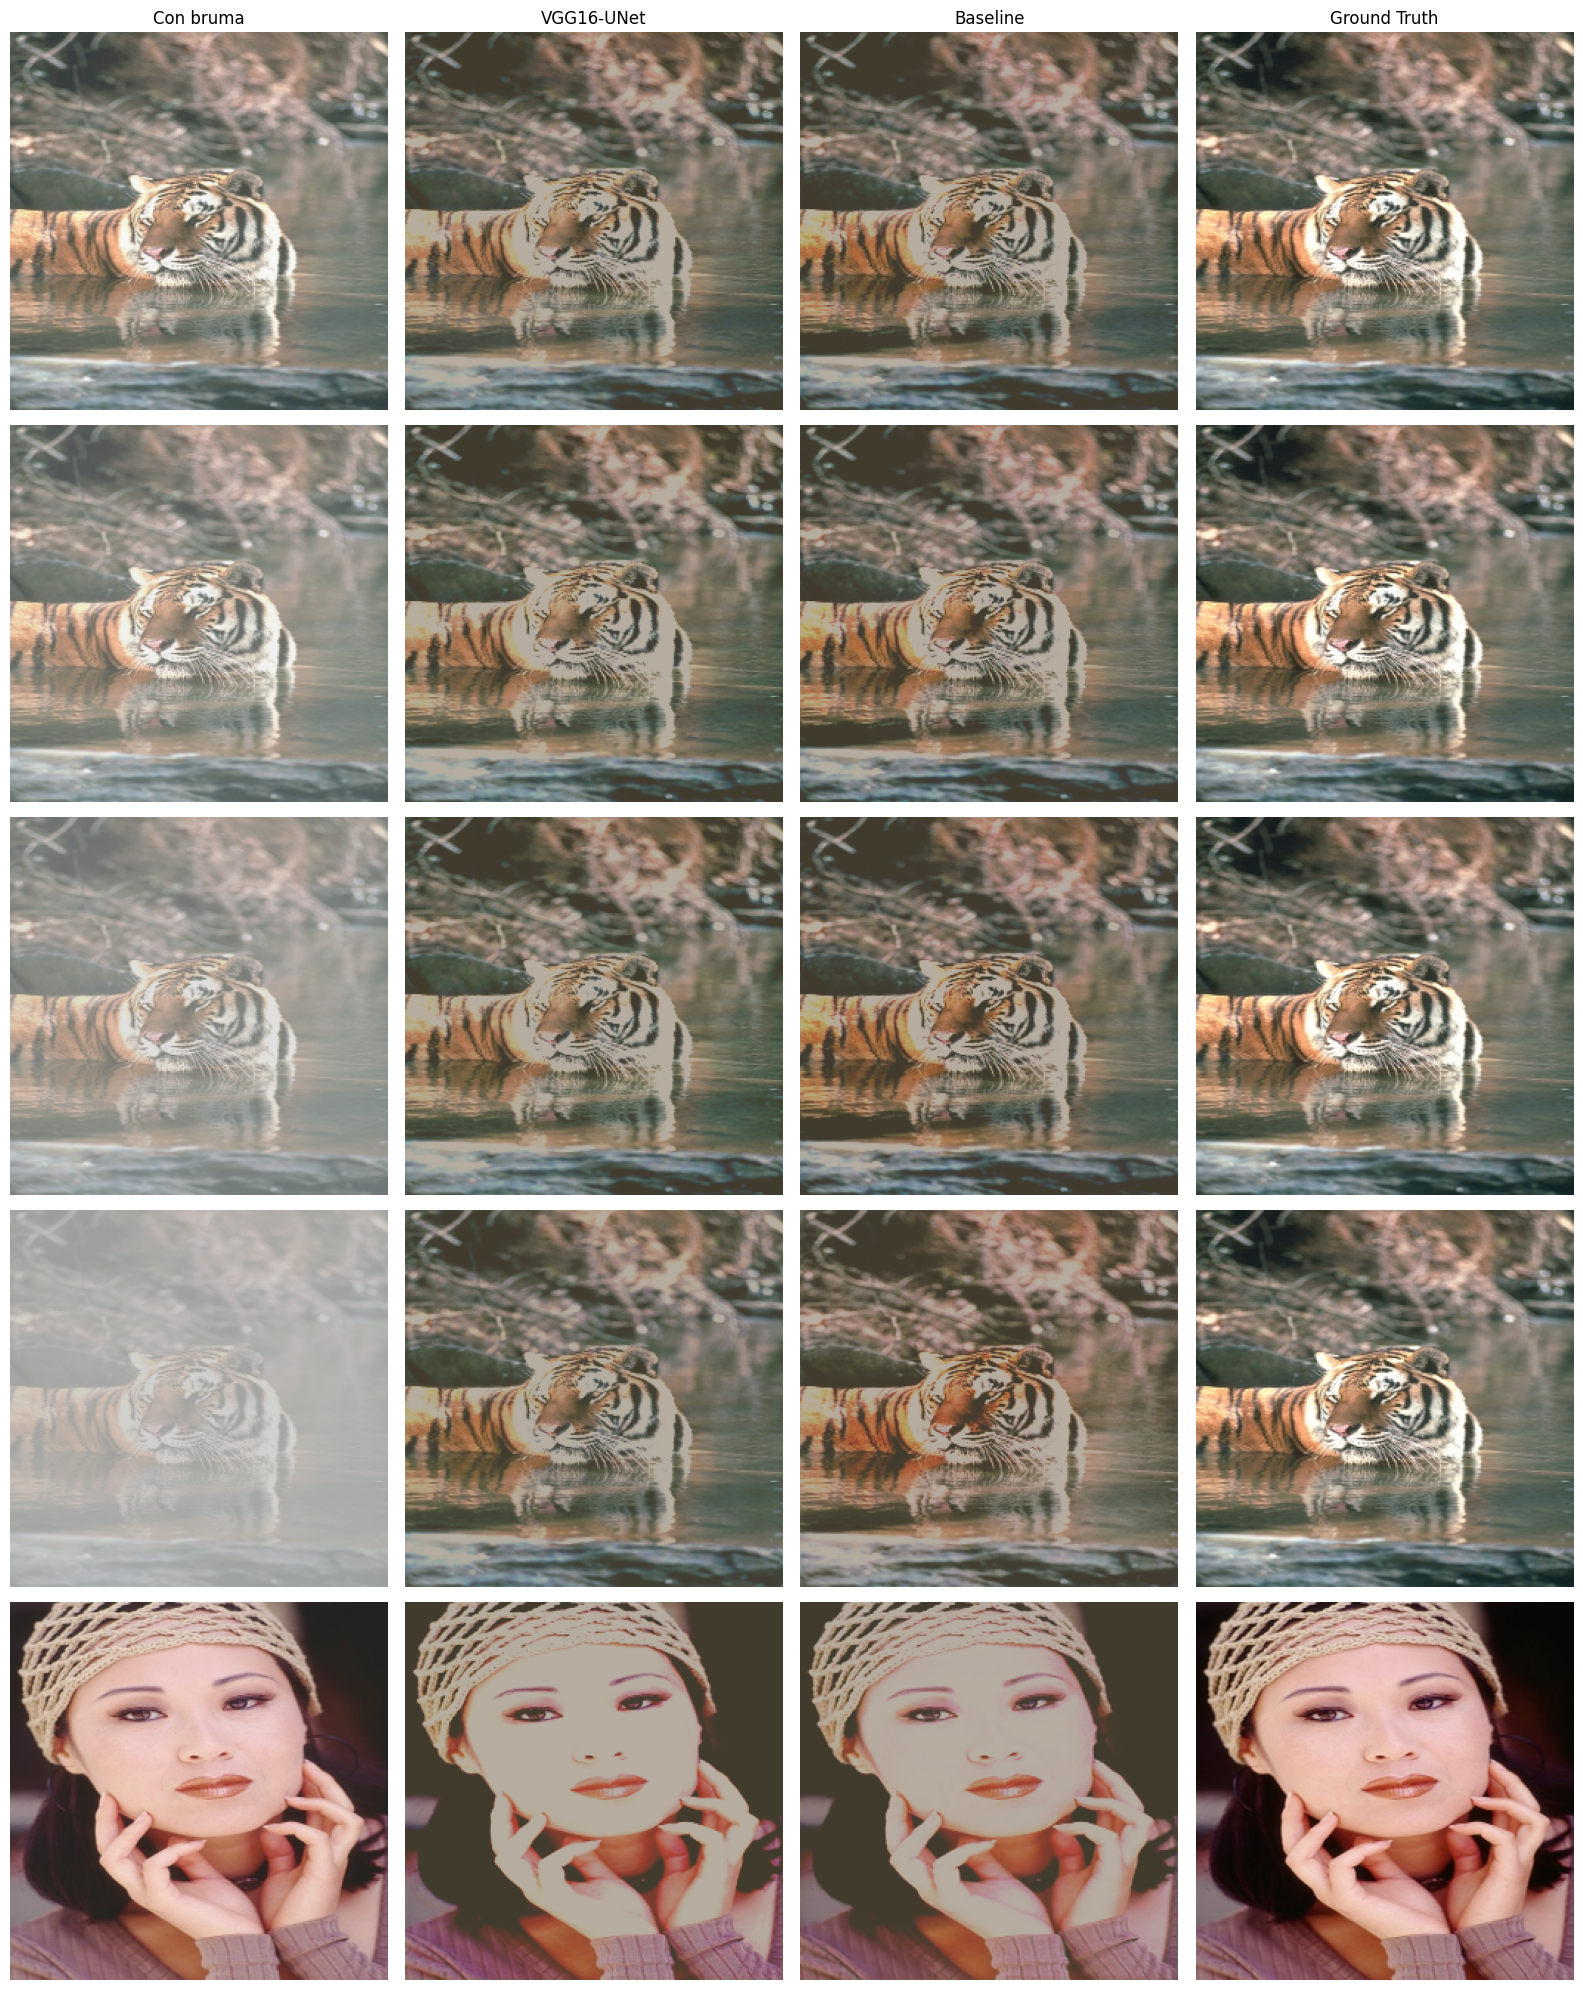

In [34]:
def denorm(t):
    mean = torch.tensor(MEAN).view(3,1,1)
    std  = torch.tensor(STD).view(3,1,1)
    return ((t.cpu() * std + mean).clamp(0,1).permute(1,2,0).numpy() * 255).astype(np.uint8)


def show_results(n=5):
    gv = VGG16UNet(PATCH_SIZE).to(DEVICE)
    gb = BaselineUNet().to(DEVICE)
    gv.load_state_dict(torch.load(CKPT_DIR / 'best_VGG16_UNet.pth',   map_location=DEVICE)['G'])
    gb.load_state_dict(torch.load(CKPT_DIR / 'best_Baseline_UNet.pth', map_location=DEVICE)['G'])
    gv.eval(); gb.eval()

    # shuffle=True para ver imagenes variadas (distinto tigre en cada fila)
    vis_loader = DataLoader(val_loader.dataset, batch_size=n,
                            shuffle=True, num_workers=2, pin_memory=True)
    x_b, y_b = next(iter(vis_loader))
    x_b = x_b.to(DEVICE)

    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            fv = gv(x_b).float().cpu()
            fb = gb(x_b).float().cpu()

    fig, axes = plt.subplots(n, 4, figsize=(16, 4*n))
    cols = ['Con bruma', 'VGG16-UNet', 'Baseline', 'Ground Truth']
    for i in range(n):
        for j, img in enumerate([x_b[i].cpu(), fv[i], fb[i], y_b[i]]):
            axes[i,j].imshow(denorm(img))
            axes[i,j].axis('off')
            if i == 0: axes[i,j].set_title(cols[j])
    plt.tight_layout()
    plt.savefig(str(DRIVE_ROOT / 'visual.png'), dpi=150)
    plt.show()


show_results()


## 13. Tabla de Resultados

In [27]:
ckpt_v = torch.load(CKPT_DIR / 'best_VGG16_UNet.pth',   map_location='cpu')
ckpt_b = torch.load(CKPT_DIR / 'best_Baseline_UNet.pth', map_location='cpu')

print('=' * 52)
print(f'{"Modelo":<22} {"Epoca":>6} {"PSNR (dB)":>12}')
print('-' * 52)
print(f'{"VGG16-UNet + DCP":<22} {ckpt_v["epoch"]:>6} {ckpt_v["psnr"]:>12.2f}')
print(f'{"Baseline U-Net":<22} {ckpt_b["epoch"]:>6} {ckpt_b["psnr"]:>12.2f}')
print('=' * 52)
print(f'Delta PSNR: {ckpt_v["psnr"] - ckpt_b["psnr"]:+.2f} dB')

Modelo                  Epoca    PSNR (dB)
----------------------------------------------------
VGG16-UNet + DCP           35        13.97
Baseline U-Net             20        13.73
Delta PSNR: +0.24 dB
